# Exploratory Data Analysis (EDA)

## Цель
Выявить паттерны, аномалии и связи в очищенных данных для подготовки к сегментации (RFM/ABC-XYZ) и построению BI-дашборда.

## Аналитические вопросы
1. Как распределены ключевые числовые признаки (возраст, траты, длительность сессии)? Есть ли выбросы?
2. Какие категории товаров формируют основную выручку?
3. Как меняется выручка и количество заказов по месяцам (сезонность)?
4. Какие признаки наиболее сильно коррелируют между собой?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Загрузка очищенных данных
customers = pd.read_csv('../data/processed/customers_clean.csv')
orders = pd.read_csv('../data/processed/orders_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
monthly = pd.read_csv('../data/processed/revenue_monthly_clean.csv')

print("Данные загружены:")
print(f"customers: {customers.shape}")
print(f"orders: {orders.shape}")

Данные загружены:
customers: (8000, 22)
orders: (25000, 29)


##Распределения и проверка выбросов

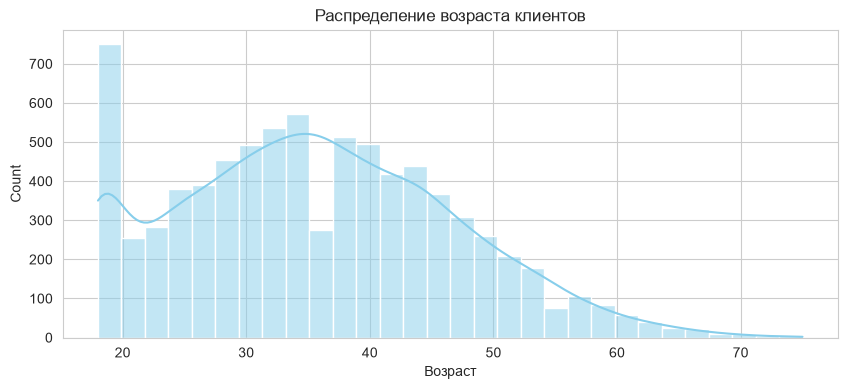

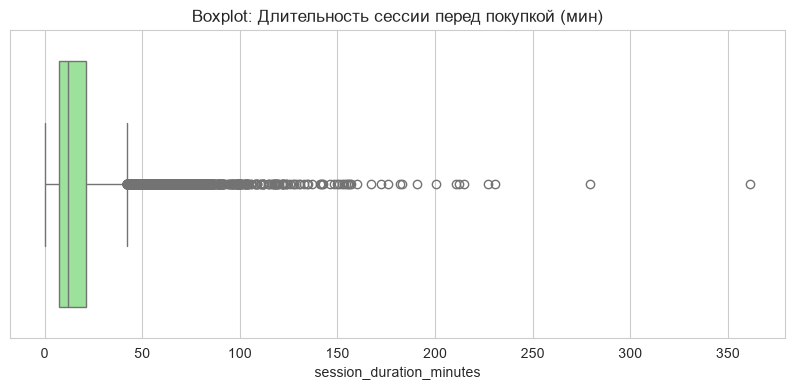

Выбросы в session_duration_minutes: 1481 из 25000 (5.9%)
Границы IQR: от -13.9 до 42.1 мин
Решение: выбросы не удаляем, так как это может быть реальное поведение (долгий выбор), но учтём в ML.


In [2]:
# 1. Распределение возраста клиентов
plt.figure(figsize=(10, 4))
sns.histplot(customers['age'], bins=30, kde=True, color='skyblue')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.show()

# 2. Выбросы в длительности сессии (session_duration_minutes)
plt.figure(figsize=(10, 4))
sns.boxplot(x=orders['session_duration_minutes'], color='lightgreen')
plt.title('Boxplot: Длительность сессии перед покупкой (мин)')
plt.show()

# Проверка IQR для session_duration_minutes (Шаг 20)
Q1 = orders['session_duration_minutes'].quantile(0.25)
Q3 = orders['session_duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = orders[(orders['session_duration_minutes'] < lower_bound) | (orders['session_duration_minutes'] > upper_bound)]

print(f"Выбросы в session_duration_minutes: {len(outliers)} из {len(orders)} ({len(outliers)/len(orders)*100:.1f}%)")
print(f"Границы IQR: от {lower_bound:.1f} до {upper_bound:.1f} мин")
print("Решение: выбросы не удаляем, так как это может быть реальное поведение (долгий выбор), но учтём в ML.")

##Агрегации: Категории и Время

/var/folders/gw/cyj6vpkn23s80_ny89rzfjwc0000gn/T/ipykernel_10514/705580862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='total_amount_usd', y='category', palette='viridis')


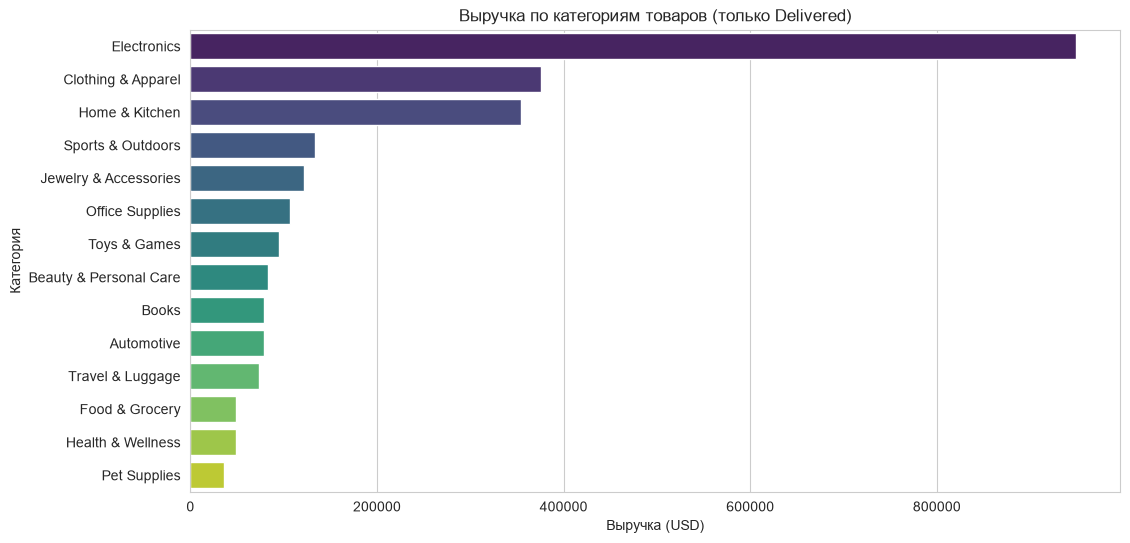

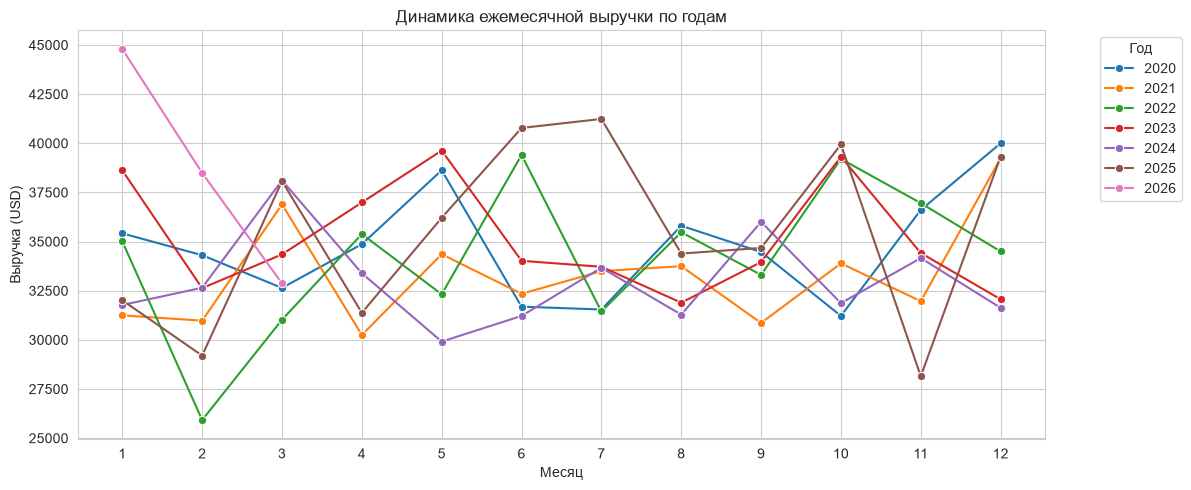

In [3]:
# 3. Выручка по категориям (используем только Delivered для честной оценки, как выяснили в ETL)
delivered_orders = orders[orders['order_status'] == 'Delivered']
cat_revenue = delivered_orders.groupby('category')['total_amount_usd'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=cat_revenue, x='total_amount_usd', y='category', palette='viridis')
plt.title('Выручка по категориям товаров (только Delivered)')
plt.xlabel('Выручка (USD)')
plt.ylabel('Категория')
plt.show()

# 4. Динамика выручки по месяцам
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='month', y='revenue_usd', hue='year', marker='o', palette='tab10')
plt.title('Динамика ежемесячной выручки по годам')
plt.xlabel('Месяц')
plt.ylabel('Выручка (USD)')
plt.xticks(range(1, 13))
plt.legend(title='Год', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##Корреляционный анализ

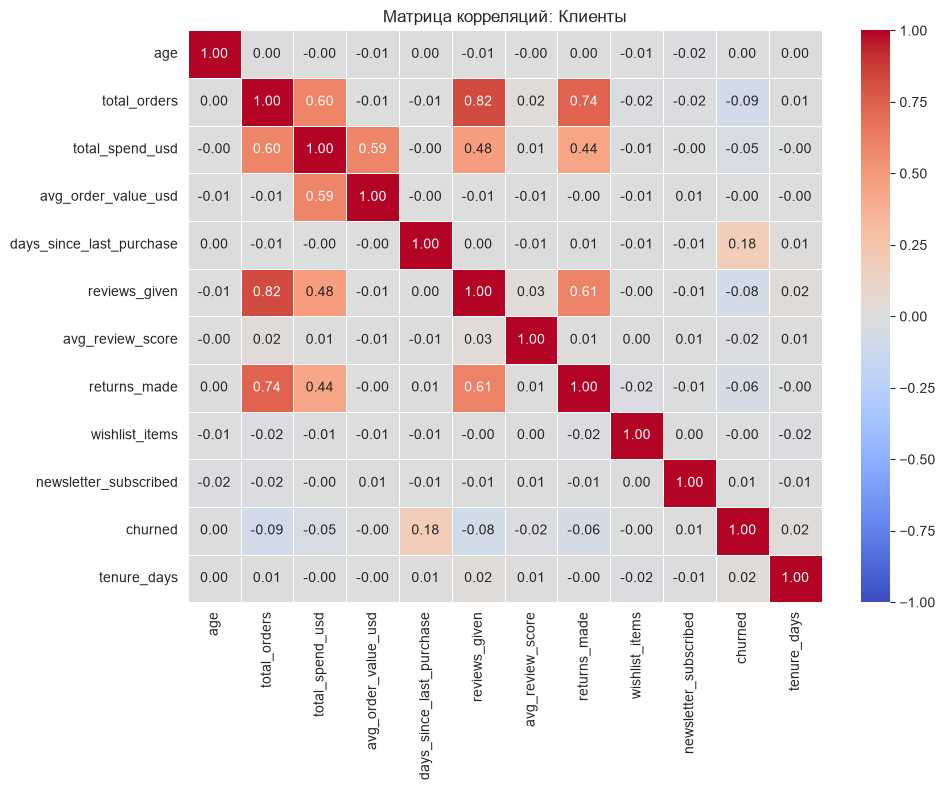

In [4]:
# 5. Корреляция числовых признаков в customers
num_cols = customers.select_dtypes(include=['number']).columns
corr_matrix = customers[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матрица корреляций: Клиенты')
plt.tight_layout()
plt.show()

## Краткие выводы по EDA
1. **Возраст**: распределён нормально, пик ~35 лет, аномалий нет.
2. **Длительность сессии**: присутствуют выбросы (> ~35 мин), но это могут быть реальные случаи долгого выбора или "зависания" в корзине. Удалять не будем, но учтём в ML-модели.
3. **Категории**: Топ-3 категории формируют основную выручку (это станет основой для ABC-анализа на следующем этапе).
4. **Сезонность**: На графике выручки видны пики (например, конец года), что требует учёта при прогнозировании.
5. **Корреляции**: `total_orders` сильно коррелирует с `total_spend_usd` (ожидаемо). `churned` имеет отрицательную связь с `total_orders` (чем больше заказов, тем ниже шанс оттока).